In [ ]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
from rasscol_src.rasscol_utils import RASSCoL

benchmark_results = Path("./benchmark_results.csv")

if not benchmark_results.exists():

    rasscol = RASSCoL()

    sequence = "QLEEIAQQLEEIAKQLKKIAWQLKKIAQGEPSAQGQLEEIAQQLEEIAKQLKKIAWQLKKIAQGPDSVQLEEIAQQLEEIAKQLKKIAWQLKKIAQGGTSGGQLEEIAQQLEEIAKQLKKIAWQLKKIAQ".lower()
    design_idx = sorted([19,44,111,16,84,114,12,51,118])
    
    sequence_list = list(sequence)
    for i in design_idx:
        sequence_list[i-1] = "A"
    sequence = "".join(sequence_list)
    
    scaffold = Path("./scapCC4.pdb")
    timing_results = []
    ligand_paths = [
        Path("./dph.pdbqt"),
        Path("./nile_red.pdbqt"),
        Path("./lumiflavin.pdbqt"),
        Path("./sn38.pdbqt"),
        Path("./arcyriaflavin.pdbqt")
    ]

    results = {}
    for ligand in ligand_paths:
        
        times = []

        for _ in range(100):
            
            start_time = time.time()
            
            # Perform docking
            rasscol.repack_pdb(scaffold, Path("./packed.pdb"), sequence, faspr_path=Path("/opt/FASPR/FASPR"), rm_seq_txt=False)
            rasscol.receptor_pdb2pdbqt(Path("./packed.pdb"), Path("./packed.pdbqt"), obabel_path=Path("/usr/bin/obabel"))
            rasscol.quick_vina(
                Path("./packed.pdbqt"), 
                ligand, 
                Path("./docked.pdbqt"), 
                [-0.6337777777777778,0.2112222222222225,1.1852222222222224], 
                [19.44,19.44,19.44]
            )
            
            end_time = time.time()
            
            times.append(end_time - start_time)
            
        results[ligand.stem] = times
    
    # save the results
    df = pd.DataFrame(results)
    df_melt = df.melt(var_name="ligand", value_name="time_s")
    df_melt['iteration'] = np.tile(np.arange(1,101), len(ligand_paths))
    df_melt[["ligand", "iteration", "time_s"]].to_csv(benchmark_results, index=False)

<Axes: xlabel='ligand', ylabel='time_s'>

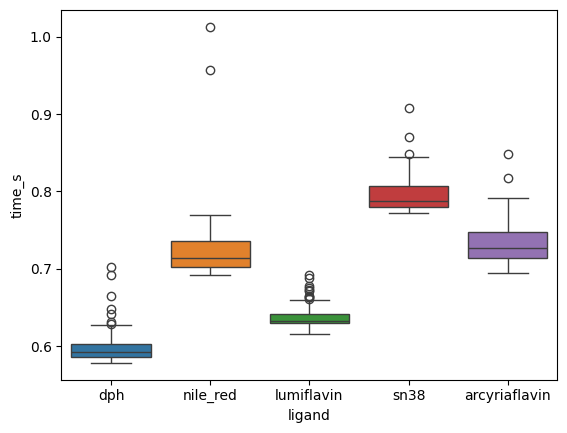

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(benchmark_results)

# first show the spread of results to see how consistent it is
sns.boxplot(data=df, x="ligand", y="time_s", hue="ligand")

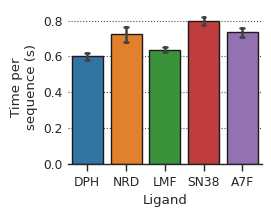

In [15]:
sns.set(style="ticks", rc={"figure.figsize": (2.5, 2)}, context="paper")
g = sns.barplot(data=df, x='ligand', y='time_s', hue='ligand', linewidth=1, edgecolor="k", palette="tab10", errorbar="sd", capsize=0.1)

g.set(xlabel='Ligand', ylabel='Time per\nsequence (s)', xticks=range(5), xticklabels=["DPH", "NRD", "LMF", "SN38", "A7F"])

# set the ytick length to 0
g.tick_params(axis='y', length=0)

# add grid lines corresponding to the ticks
g.yaxis.grid(True, linestyle=':', color='.3')

sns.despine(left=True)

plt.savefig("./benchmark_results.png", bbox_inches="tight", dpi=500, transparent=False)

In [14]:
display(df.groupby("ligand").mean().round(2))
df.groupby("ligand").std()

,iteration,time_s
ligand,,
arcyriaflavin,50.5,0.73
dph,50.5,0.60
lumiflavin,50.5,0.64
nile_red,50.5,0.72
sn38,50.5,0.80


,iteration,time_s
ligand,,
arcyriaflavin,29.011492,0.026646
dph,29.011492,0.021603
lumiflavin,29.011492,0.014538
nile_red,29.011492,0.042576
sn38,29.011492,0.022585
